# Tourism employment in the Canary Islands (2005-2015)

**Dataset**: Empresas segun actividades turisticas CNAE-09, islas de Canarias y periodos

**Source**: [ISTAC](https://datos.canarias.es) - quarterly companies registered with Social Security in tourism activities by island

**Question**: How did tourism employment evolve across Canary Islands? Which activities grew or contracted? How did the 2008 crisis impact the sector?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
OUTPUT_DIR = Path("output/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = "data/raw/tourism-employment-canary-islands.csv"
df = pd.read_csv(CSV_PATH)
print("Rows:", len(df), "| Columns:", len(df.columns))
df.head(2)

Rows: 7392 | Columns: 7


,islas_id,islas_nombre,actividades_turisticas_cnae_09_id,actividades_turisticas_cnae_09_nombre,periodos_id,periodos_nombre,empresas_segun_actividades_turisticas_cnae_09_islas_canarias_periodos
0,0,Total,0,Total,2015M06,2015 Junio,15131
1,0,Total,0,Total,2015M03,2015 Marzo,15410


In [2]:
# Rename columns for convenience
df = df.rename(columns={
    "islas_nombre": "island",
    "actividades_turisticas_cnae_09_nombre": "activity",
    "periodos_id": "quarter",
    "empresas_segun_actividades_turisticas_cnae_09_islas_canarias_periodos": "companies"
})

# Month to quarter mapping: M03=Q1, M06=Q2, M09=Q3, M12=Q4
month_to_q = {3: 1, 6: 2, 9: 3, 12: 4}

df["year"] = df["quarter"].str[:4].astype(int)
df["month"] = df["quarter"].str[-2:].astype(int)
df["q"] = df["month"].map(month_to_q)
df["date"] = pd.to_datetime(
    df["year"].astype(str) + "-" + (df["q"] * 3 - 2).astype(str).str.zfill(2) + "-01"
)

# Sort
df = df.sort_values(["island", "activity", "quarter"])

print("Islands:", sorted(df["island"].unique()))
print("Activities:", len(df["activity"].unique()))
print("Quarter range:", df["quarter"].min(), "->", df["quarter"].max())
print("Total island rows:", len(df[df["island"]=="Total"]))

Islands: ['El Hierro', 'Fuerteventura', 'Gran Canaria', 'La Gomera', 'La Palma', 'Lanzarote', 'Tenerife', 'Total']
Activities: 22
Quarter range: 2005M03 -> 2015M06
Total island rows: 924


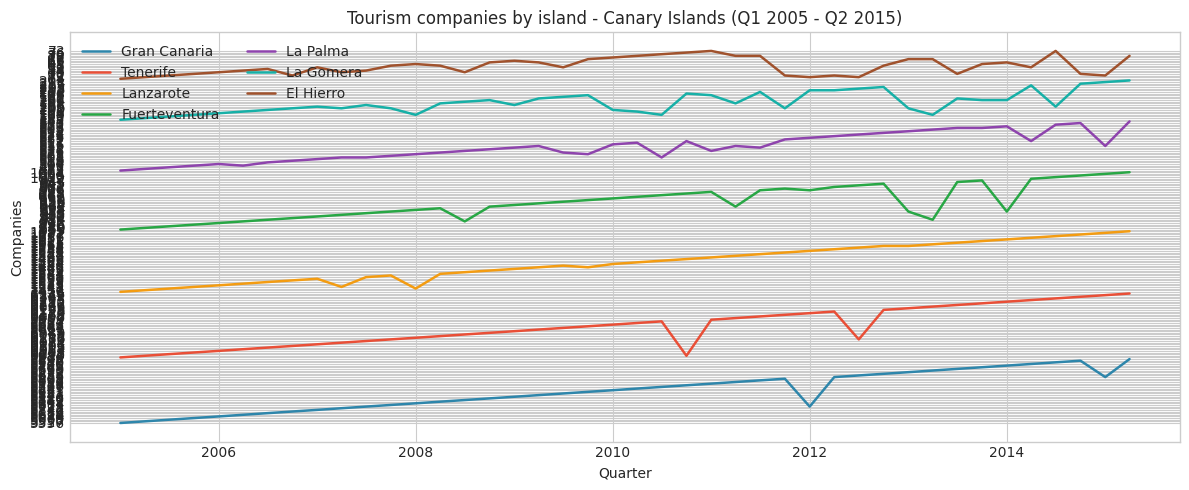

Saved: output/figures/tourism_employment_by_island.png


In [3]:
# 1. Total tourism companies by island - quarterly trend
fig, ax = plt.subplots(figsize=(12, 5))

islands = ["Gran Canaria", "Tenerife", "Lanzarote", "Fuerteventura", "La Palma", "La Gomera", "El Hierro"]
colors7 = {
    "Gran Canaria": "#2E86AB",
    "Tenerife": "#E94F37",
    "Lanzarote": "#F39C12",
    "Fuerteventura": "#28A745",
    "La Palma": "#8E44AD",
    "La Gomera": "#17B0A7",
    "El Hierro": "#A0522D"
}

total_df = df[(df["island"] != "Total") & (df["activity"] == "Total")]
for isl in islands:
    d = total_df[total_df["island"] == isl].sort_values("date")
    ax.plot(d["date"], d["companies"], label=isl, color=colors7[isl], linewidth=1.8)

ax.set_xlabel("Quarter")
ax.set_ylabel("Companies")
ax.set_title("Tourism companies by island - Canary Islands (Q1 2005 - Q2 2015)")
ax.legend(loc="upper left", ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "tourism_employment_by_island.png", dpi=150)
plt.show()
print("Saved: output/figures/tourism_employment_by_island.png")

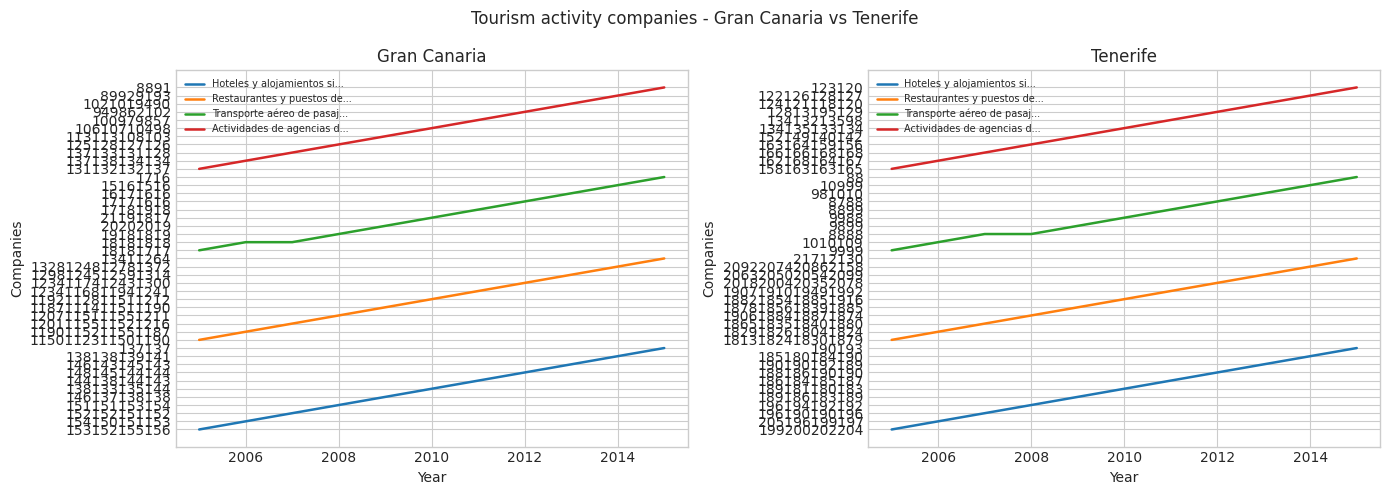

Saved: output/figures/tourism_employment_gc_vs_tenerife_activities.png


In [4]:
# 2. Top activities - Gran Canaria and Tenerife, annual totals
annual_act = df[(df["island"] != "Total") & (df["activity"] != "Total")].groupby(["year", "island", "activity"])["companies"].sum().reset_index()

top_acts = ["Hoteles y alojamientos similares", "Restaurantes y puestos de comidas",
            "Transporte aereo de pasajeros", "Actividades de agencias de viajes y operadores turisticos"]

# Normalize activity names for matching
act_name_map = {a: a.lower().replace(" ", "_").replace(",", "").replace("_", "_") for a in df["activity"].unique()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, isl in zip(axes, ["Gran Canaria", "Tenerife"]):
    for orig_act in ["Hoteles y alojamientos similares", "Restaurantes y puestos de comidas",
                     "Transporte aéreo de pasajeros", "Actividades de agencias de viajes y operadores turísticos"]:
        d = annual_act[(annual_act["island"] == isl) & (annual_act["activity"] == orig_act)]
        if len(d) > 0:
            label = orig_act[:25] + "..." if len(orig_act) > 25 else orig_act
            ax.plot(d["year"], d["companies"], label=label, linewidth=1.8)
    ax.set_title(isl)
    ax.set_xlabel("Year")
    ax.set_ylabel("Companies")
    ax.legend(fontsize=7, loc="upper left")

fig.suptitle("Tourism activity companies - Gran Canaria vs Tenerife")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "tourism_employment_gc_vs_tenerife_activities.png", dpi=150)
plt.show()
print("Saved: output/figures/tourism_employment_gc_vs_tenerife_activities.png")

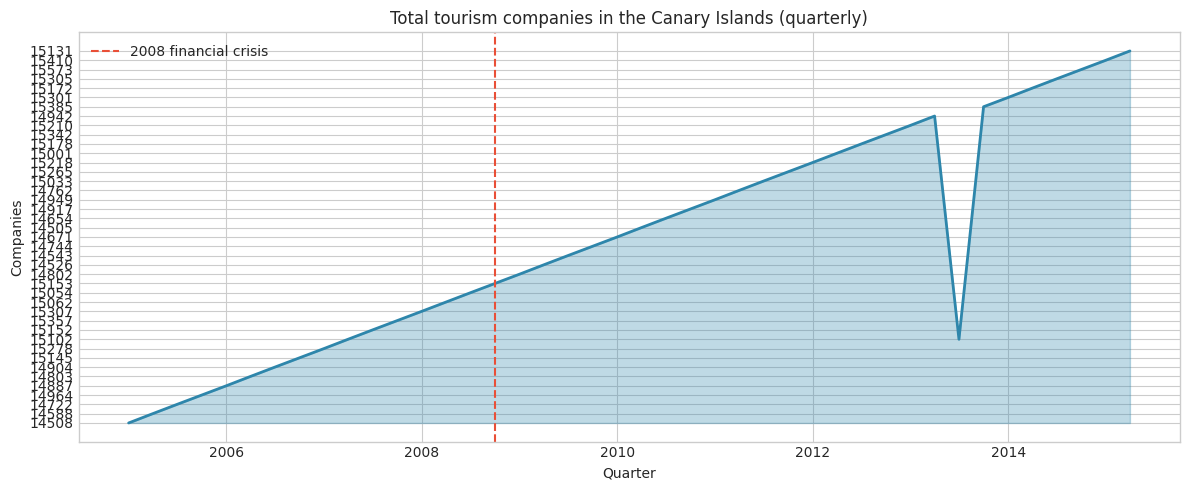

Saved: output/figures/tourism_employment_total_trend.png


In [5]:
# 3. Total tourism companies - all islands quarterly trend
fig, ax = plt.subplots(figsize=(12, 5))
total_all = df[(df["island"] == "Total") & (df["activity"] == "Total")].sort_values("date")
ax.plot(total_all["date"], total_all["companies"], color="#2E86AB", linewidth=2)
ax.fill_between(total_all["date"], total_all["companies"], alpha=0.3, color="#2E86AB")

# Mark 2008 crisis
crisis_date = pd.Timestamp("2008-10-01")
ax.axvline(crisis_date, color="#E94F37", linestyle="--", linewidth=1.5, label="2008 financial crisis")
ax.set_xlabel("Quarter")
ax.set_ylabel("Companies")
ax.set_title("Total tourism companies in the Canary Islands (quarterly)")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "tourism_employment_total_trend.png", dpi=150)
plt.show()
print("Saved: output/figures/tourism_employment_total_trend.png")

In [6]:
# 4. Key numbers
print("Latest quarter (2015-Q2) totals by island:")
latest = df[(df["quarter"]=="2015M06") & (df["island"]!="Total") & (df["activity"]=="Total")].sort_values("companies", ascending=False)
for _, row in latest.iterrows():
    print("  " + row["island"] + ": " + str(int(row["companies"])) + " companies")

print()
print("2008 vs 2015 total tourism companies:")
for yr, q in [("2008", "2008M12"), ("2015", "2015M06")]:
    val = df[(df["quarter"]==q) & (df["island"]=="Total") & (df["activity"]=="Total")]["companies"].values[0]
    print("  " + yr + ": " + str(int(val)) + " companies")

Latest quarter (2015-Q2) totals by island:
  El Hierro: 78 companies
  Tenerife: 6236 companies
  La Palma: 545 companies
  Gran Canaria: 5392 companies
  La Gomera: 201 companies
  Lanzarote: 1675 companies
  Fuerteventura: 1004 companies

2008 vs 2015 total tourism companies:
  2008: 15153 companies
  2015: 15131 companies
